

```
# Выбран кодовый формат
```

# Random Forest: роль случайного выбора признаков

В этой задаче нужно экспериментально исследовать, как параметр `max_features` влияет на качество `RandomForestRegressor`.

Параметр `max_features` задаёт, сколько признаков рассматривается при поиске лучшего split в каждой вершине дерева.

Рассмотрите модели:

```python
RandomForestRegressor(max_features=1.0)
RandomForestRegressor(max_features=0.7)
RandomForestRegressor(max_features=0.5)
RandomForestRegressor(max_features="sqrt")
RandomForestRegressor(max_features=0.3)
```

Меньшие значения `max_features` добавляют дополнительную случайность: деревья становятся менее похожими друг на друга, но отдельные split могут стать слабее.

## Эксперимент

1. Возьмите несколько регрессионных датасетов:
   - `load_diabetes`;
   - `make_friedman1`;
   - ещё один датасет по выбору.

2. Для каждого датасета сделайте несколько случайных train/test-разбиений.

3. Для каждого значения `max_features` обучите `RandomForestRegressor` с одинаковым числом деревьев, например:

```python
n_estimators = 300
```

4. Для каждой модели посчитайте test RMSE и test $R^2$.

5. Для каждого датасета постройте таблицу со средним и стандартным отклонением RMSE и $R^2$ по разным разбиениям.

6. Для одного датасета постройте график зависимости test RMSE от `max_features`.

## Вопросы для вывода

- Всегда ли `max_features="sqrt"` лучше, чем `max_features=1.0`?
- На каких данных случайный выбор признаков помогает?
- На каких данных он ухудшает качество?
- Как можно объяснить разные результаты на разных датасетах?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes, make_friedman1, fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
diabetes = load_diabetes()
X_friedman, y_friedman = make_friedman1(n_samples=500, n_features=10, random_state=42)
california = fetch_california_housing()

datasets = {
    "Diabetes": (diabetes.data, diabetes.target),
    "Friedman1": (X_friedman, y_friedman),
    "California Housing": (california.data, california.target)
}

In [5]:
# Параметры эксперимента
max_features_list = [1.0, 0.7, 0.5, "sqrt", 0.3]
n_splits = 5
n_estimators = 300

results = defaultdict(lambda: defaultdict(list))

In [6]:
for ds_name, (X, y) in datasets.items():
    print(f"Processing {ds_name}...")

    for split in range(n_splits):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42 + split
        )

        for mf in max_features_list:
            # Обучаем модель
            model = RandomForestRegressor(
                n_estimators=n_estimators,
                max_features=mf,
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)

            # Предсказание и метрики
            y_pred = model.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)

            # Сохраняем в строковом формате для ключа (чтобы "sqrt" и 1.0 были в одном стиле)
            mf_str = str(mf)
            results[ds_name][mf_str].append({"RMSE": rmse, "R2": r2})

print("\nЭксперимент завершен!")

Processing Diabetes...
Processing Friedman1...
Processing California Housing...

Эксперимент завершен!


In [13]:
for ds_name in datasets.keys():
    summary_data = []
    for mf in max_features_list:
        mf_str = str(mf)
        metrics = results[ds_name][mf_str]

        rmses = [m["RMSE"] for m in metrics]
        r2s = [m["R2"] for m in metrics]

        summary_data.append({
            "max_features": mf_str,
            "RMSE (mean)": np.mean(rmses),
            "RMSE (std)": np.std(rmses),
            "R² (mean)": np.mean(r2s),
            "R² (std)": np.std(r2s)
        })

    df_summary = pd.DataFrame(summary_data)
    print(f"\n--- Таблица для датасета: {ds_name} ---")
    print(df_summary.to_string(index=False, formatters={
        "RMSE (mean)": "{:.4f}".format, "RMSE (std)": "{:.4f}".format,
        "R² (mean)": "{:.4f}".format, "R² (std)": "{:.4f}".format
    }))


--- Таблица для датасета: Diabetes ---
max_features RMSE (mean) RMSE (std) R² (mean) R² (std)
         1.0     57.5522     4.0062    0.4153   0.0469
         0.7     57.6309     3.8153    0.4138   0.0423
         0.5     57.1709     4.0824    0.4234   0.0435
        sqrt     56.6678     3.7082    0.4335   0.0361
         0.3     56.6678     3.7082    0.4335   0.0361

--- Таблица для датасета: Friedman1 ---
max_features RMSE (mean) RMSE (std) R² (mean) R² (std)
         1.0      1.9777     0.0559    0.8314   0.0259
         0.7      1.9350     0.0553    0.8388   0.0233
         0.5      1.9461     0.0573    0.8369   0.0245
        sqrt      2.0829     0.0554    0.8143   0.0172
         0.3      2.0829     0.0554    0.8143   0.0172

--- Таблица для датасета: California Housing ---
max_features RMSE (mean) RMSE (std) R² (mean) R² (std)
         1.0      0.4962     0.0115    0.8153   0.0085
         0.7      0.4900     0.0110    0.8199   0.0081
         0.5      0.4845     0.0102    0.824

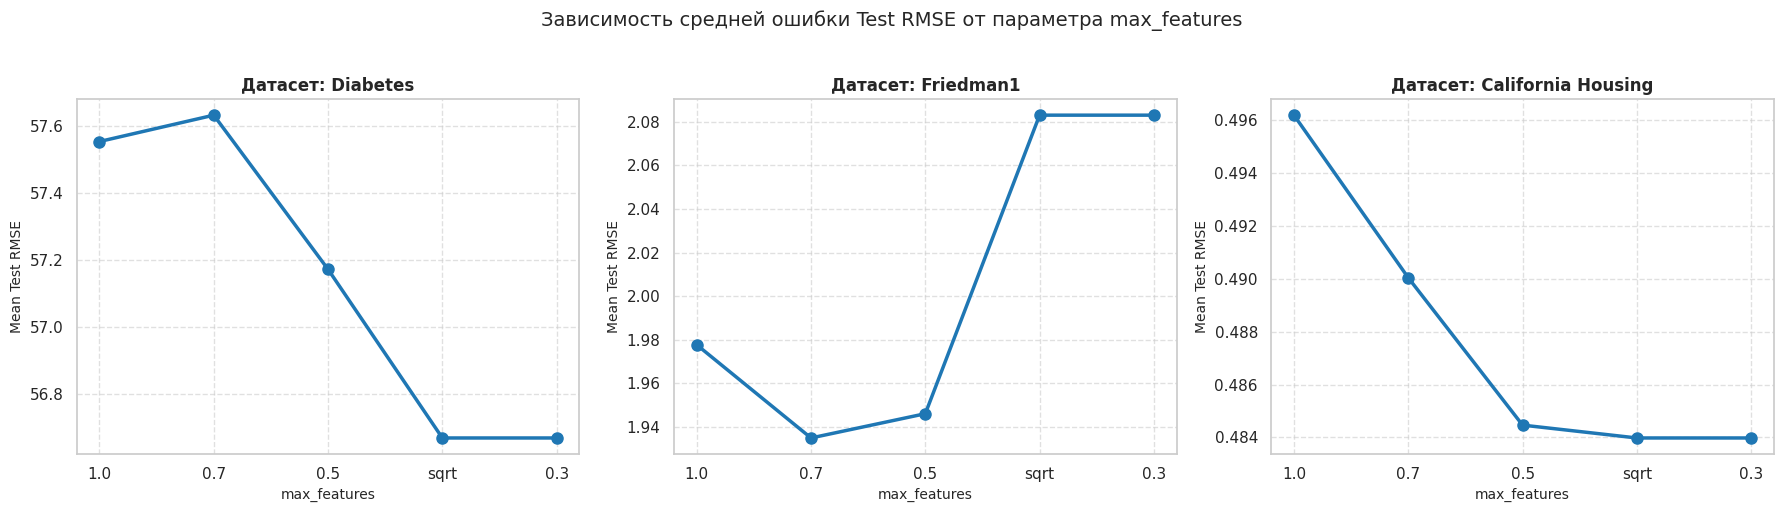

In [16]:
# --- Построение простых линейных графиков для всех датасетов ---

# Создаем сетку из 3 графиков в один ряд
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)

for i, ds_name in enumerate(datasets.keys()):
    means_rmse = []

    # Извлекаем средние значения RMSE строго по порядку из max_features_list
    for mf in max_features_list:
        mf_str = str(mf)
        metrics = results[ds_name][mf_str]
        rmses = [m["RMSE"] for m in metrics]
        means_rmse.append(np.mean(rmses))

    # Строим обычный линейный график с точками на изломах
    axes[i].plot(
        [str(mf) for mf in max_features_list],  # Ось X (строковые метки)
        means_rmse,                            # Ось Y (среднее RMSE)
        marker='o',                            # Точки на графике
        linewidth=2.5,                         # Толщина линии
        markersize=8,                          # Размер точек
        color='#1f77b4'                        # Спокойный синий цвет
    )

    # Настройка названий и сеток для каждого графика
    axes[i].set_title(f"Датасет: {ds_name}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("max_features", fontsize=10)
    axes[i].set_ylabel("Mean Test RMSE", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Зависимость средней ошибки Test RMSE от параметра max_features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

* Всегда ли max_features="sqrt" лучше, чем max_features=1.0?

 Нет, не всегда. График для Friedman1 наглядно это опровергает: при переходе к "sqrt" ошибка RMSE резко возрастает. Ограничение количества признаков до квадратного корня часто декомпенсирует регрессионные деревья, делая их слишком слабыми («глупыми») для точного предсказания непрерывной величины, поэтому в регрессии дефолтный 1.0 или значения 0.5–0.7 нередко выигрывают у sqrt.

* На каких данных случайный выбор признаков помогает?

Ограничение max_features эффективно на реальных, избыточных данных с высокой корреляцией признаков (как Diabetes и California Housing). В таких датасетах без ограничений деревья строятся по одним и тем же доминантным фичам и становятся «близнецами». Случайный выбор заставляет их искать альтернативные связи, что сильно декоррелирует деревья и снижает общую дисперсию (variance) ансамбля, улучшая качество на тесте.

* На каких данных он ухудшает качество?

Случайный выбор признаков ухудшает качество на синтетических или калиброванных данных, где присутствует много шумовых фич и мало сигнальных (как в Friedman1). Если из 10 признаков важны только 5, а max_features урезан до 3, то в узлы дерева постоянно будет попадать исключительно случайный шум. Модель теряет ключевой сигнал, не может построить адекватные разделения и критически недообучается (растет bias).

* Как можно объяснить разные результаты на разных датасетах?

 Разница объясняется структурой данных: в Diabetes (10 фич) медицинские показатели дублируют друг друга, и случайность спасает от переобучения; в California Housing (8 фич) сложный реальный ландшафт требует жесткой регуляризации ансамбля. Напротив, в Friedman1 (10 фич, из которых 5 — шум) жесткое ограничение лишает модель доступа к реальным нелинейным взаимосвязям, заставляя деревья дробить выборку по случайным шумовым координатам.